# Predicting category switching

## 1. Project overview

### 1.1 Business problem
An e-commerce website could use browsing behavior to decide whether to keep showing
products from the current category or introduce products from other categories.
This notebook predicts category switching. It does not build a complete recommendation system.

### 1.2 Research question
> Can users' current and historical browsing behavior help predict whether they will switch to another product category on their next click?

- **RQ1:** How well can current browsing information predict category switching?
- **RQ2:** Does adding browsing history improve switch prediction?

### 1.3 Target
> Given that there is another click in the session, will the next click remain in the current category or switch to another category?

- `switch_category = 0`: the next category is the same (**Stay**).
- `switch_category = 1`: the next category is different (**Switch**).

The model does not predict whether a user leaves the website or ends the session.

**Switch = 1 is the positive class and the business-interest class.**
Features are the information available to the model at the current click.
We compare **Current** with **Current + History**, using the same observations and session split.

## 2. Data understanding

### 2.1 Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 14)

### 2.2 Load dataset


In [2]:
df = pd.read_csv("e-shop clothing 2008.csv")
display(df.head())
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


Rows and columns: (165474, 14)
Column names: ['year', 'month', 'day', 'order', 'country', 'session ID', 'page 1 (main category)', 'page 2 (clothing model)', 'colour', 'location', 'model photography', 'price', 'price 2', 'page']


### 2.3 Dataset structure

The local `e-shop clothing 2008 data description.txt` describes these variables:

| Variable | Meaning |
| --- | --- |
| `session ID` | A browsing session, not a known customer identity |
| `order` | Click sequence within that session |
| `page 1 (main category)` | 1 = Trousers, 2 = Skirts, 3 = Blouses, 4 = Sale |
| `page 2 (clothing model)` | A product code |
| `price` | Current product price in US dollars |
| `colour` | Product colour code |
| `location` | Product photo position in one of six screen areas |
| `model photography` | Front view or profile view |
| `page` | Catalogue page number, from 1 to 5 |
| `price 2` | Whether price is above the category average |

The data cover April to August 2008. A click records browsing, not a purchase.

### 2.4 Basic data quality checks

In [3]:
df.info()
display(df.isna().sum().rename("Missing values").to_frame())
print("Duplicate rows:", df.duplicated().sum())
print("Sessions:", df["session ID"].nunique())
print("Clothing models:", df["page 2 (clothing model)"].nunique())

assert not df.isna().any().any()
assert not df.duplicated().any()
assert not df.duplicated(["session ID", "order"]).any()
assert set(df["page 1 (main category)"]) == {1, 2, 3, 4}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  int64 
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  int64 
 9   location                 165474 non-null  int64 
 10  model photography        165474 non-null  int64 
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  int64 
 13  page                     165474 non-null  int64 
dtypes: int64(13), object

,Missing values
year,0
month,0
day,0
order,0
country,0
session ID,0
page 1 (main category),0
page 2 (clothing model),0
colour,0
location,0


Duplicate rows: 0
Sessions: 24026
Clothing models: 217


The data contain 165,474 clicks in 24,026 sessions,
with 217 clothing models. There are no missing values, duplicate rows, or duplicate
session-position pairs. We can construct click sequences without deleting or filling raw observations.

## 3. Target and feature construction

Sort before using `shift()` or `cumcount()`. They follow row order, so clicks must
be in sequence within each session. `shift(-1)` reads the next click to create the
target only. That future category must never be a model input.

### 3.1 Sort click sequences

In [4]:
df = df.sort_values(["session ID", "order"]).copy()

### 3.2 Create next_category

In [5]:
df["next_category"] = (
    df.groupby("session ID")["page 1 (main category)"].shift(-1)
)

### 3.3 Create switch_category

In [6]:
df["switch_category"] = (
    df["next_category"] != df["page 1 (main category)"]
).astype(int)

### 3.4 Create historical features

- `prev_category`: previous category; 0 explicitly means no previous click.
- `same_category_prev`: -1 = no previous click, 0 = different, 1 = same.
- `category_visit_count`: visits to the current category **before** this click.

These features use past clicks within the same session. The current category is
already known when predicting the next click.

In [7]:
df["prev_category"] = (
    df.groupby("session ID")["page 1 (main category)"].shift(1)
)
df["prev_category"] = df["prev_category"].fillna(0).astype(int)
df["same_category_prev"] = np.where(
    df["prev_category"] == 0,
    -1,
    (df["prev_category"] == df["page 1 (main category)"]).astype(int)
)
df["category_visit_count"] = (
    df.groupby(["session ID", "page 1 (main category)"]).cumcount()
)

`cumcount()` starts at zero. It excludes the current click and all later clicks.
A total session count would include future visits and cause data leakage,
which means giving a model information it would not have at prediction time.

### 3.5 Create modeling dataset
Retain first and middle clicks when a next click exists. Remove only final clicks.
The following two sessions let us check the features against the original sequence.

In [8]:
df_model = df[df["next_category"].notna()].copy()
print("Raw clicks:", len(df))
print("Removed final clicks:", len(df) - len(df_model))
print("Rows with a target:", len(df_model))
print("Retained first clicks:", df_model["prev_category"].eq(0).sum())

Raw clicks: 165474
Removed final clicks: 24026
Rows with a target: 141448
Retained first clicks: 18984


In session 1, click 1 has no previous category and zero earlier visits. Click 2 has
one earlier visit to Trousers and switches next to Skirts. On click 3, the earlier
visit count for Skirts is zero. The removed final click still supplies the next
category for the preceding row.

### 3.6 Sequence sanity check

In [9]:
example_columns = [
    "session ID", "order", "page 1 (main category)", "prev_category",
    "same_category_prev", "category_visit_count", "next_category", "switch_category"
]
display(df_model.loc[df_model["session ID"].isin([1]), example_columns])

,session ID,order,page 1 (main category),prev_category,same_category_prev,category_visit_count,next_category,switch_category
0,1,1,1,0,-1,0,1.0,0
1,1,2,1,1,1,1,2.0,1
2,1,3,2,1,0,0,2.0,0
3,1,4,2,2,1,1,2.0,0
4,1,5,2,2,1,2,3.0,1
5,1,6,3,2,0,0,3.0,0
6,1,7,3,3,1,1,4.0,1
7,1,8,4,3,0,0,4.0,0


## 4. Train/test split by session
Use one 80/20 session split for all models, before exploring training data.
A row-level split could put related clicks in both sets and inflate test performance.
This evaluates unseen sessions, not necessarily unseen people. No cross-validation is used.

In [10]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_index, test_index = next(
    splitter.split(df_model, groups=df_model["session ID"])
)
train_df = df_model.iloc[train_index].copy()
test_df = df_model.iloc[test_index].copy()
train_sessions = train_df["session ID"].unique()
test_sessions = test_df["session ID"].unique()

assert set(train_sessions).isdisjoint(set(test_sessions))
print("Train rows / sessions:", len(train_df), len(train_sessions))
print("Test rows / sessions:", len(test_df), len(test_sessions))
print("Overlapping sessions:", len(set(train_sessions) & set(test_sessions)))

Train rows / sessions: 112491 15187
Test rows / sessions: 28957 3797
Overlapping sessions: 0


## 5. Exploratory data analysis
All eight plots use **training clicks with an observed next click**. Tables include
counts because groups have different sizes. Longer sessions contribute more clicks;
the observed associations do not establish causation.

### 5.1 Target distribution

,Count,Share (%)
switch_category,,
Stay,91257,81.12
Switch,21234,18.88


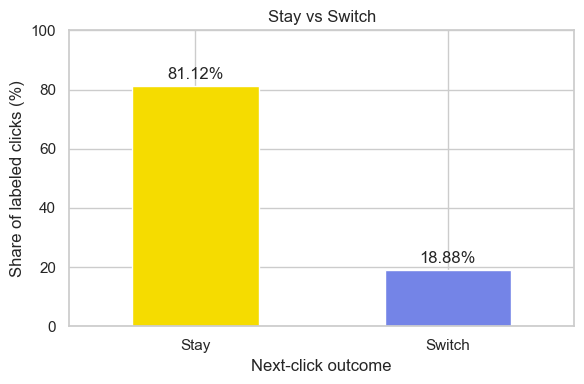

In [11]:
target_counts = train_df["switch_category"].value_counts().reindex([0, 1])
target_summary = pd.DataFrame({
    "Count": target_counts,
    "Share (%)": 100 * target_counts / target_counts.sum()
}).rename(index={0: "Stay", 1: "Switch"})
display(target_summary.round(2))

ax = target_summary["Share (%)"].plot.bar(rot=0, color=["#F5DC00", "#7484E7"], figsize=(6, 4))
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=3)
ax.set(title="Stay vs Switch", xlabel="Next-click outcome", ylabel="Share of labeled clicks (%)", ylim=(0, 100))
plt.tight_layout()
plt.show()

Switch represents 18.88% of training clicks. Always predicting Stay can therefore
look accurate while missing every switch. We need Switch precision, recall, and F1
to evaluate detection of the minority class.

### 5.2 Switch rate by current category

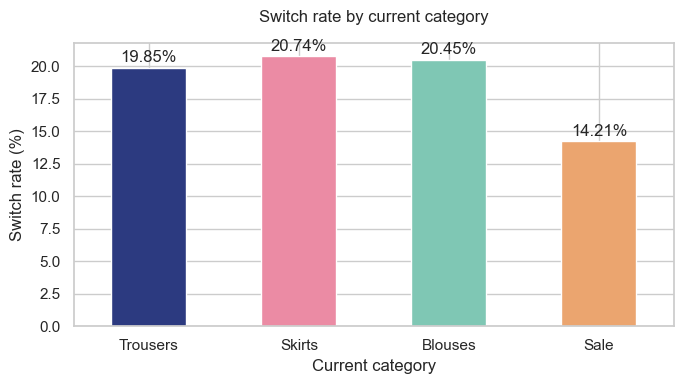

In [12]:
category_names = {1: "Trousers", 2: "Skirts", 3: "Blouses", 4: "Sale"}
category_rates = train_df.groupby("page 1 (main category)")["switch_category"].agg(
    ["size", "mean"]
).rename(index=category_names, columns={"size": "Clicks", "mean": "Switch rate"})
ax = (100 * category_rates["Switch rate"]).plot.bar(rot=0, color = ["#2C3A80", "#EB8BA4", "#7FC7B4", "#EBA56F"], figsize=(7, 4))
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=2)
ax.set_title("Switch rate by current category", pad=15)
ax.set(xlabel="Current category", ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

Sale has a switch rate of 14.21%,
compared with 20.74% for Skirts. This variation supports
retaining current category. It describes an association, not an effect caused by the category.

### 5.3 Switch rate by browsing position

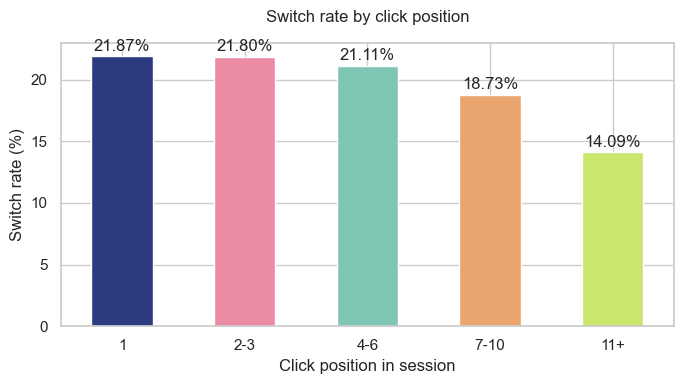

In [13]:
order_groups = pd.cut(
    train_df["order"], bins=[0, 1, 3, 6, 10, np.inf],
    labels=["1", "2-3", "4-6", "7-10", "11+"]
)
order_rates = train_df.groupby(order_groups, observed=True)["switch_category"].agg(
    ["size", "mean"]
)
ax = (100 * order_rates["mean"]).plot.bar(rot=0, color = ["#2C3A80", "#EB8BA4", "#7FC7B4", "#EBA56F", "#CAE66D"], figsize=(7, 4))
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=2)
ax.set_title("Switch rate by click position", pad=15)
ax.set(xlabel="Click position in session", ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

The switch rate falls from 21.87% at the first click
to 14.09% at positions 11 and later. Retain `order` as current context.
This comparison also reflects which sessions continue long enough to reach later positions.

### 5.4 Switch rate by recent category consistency

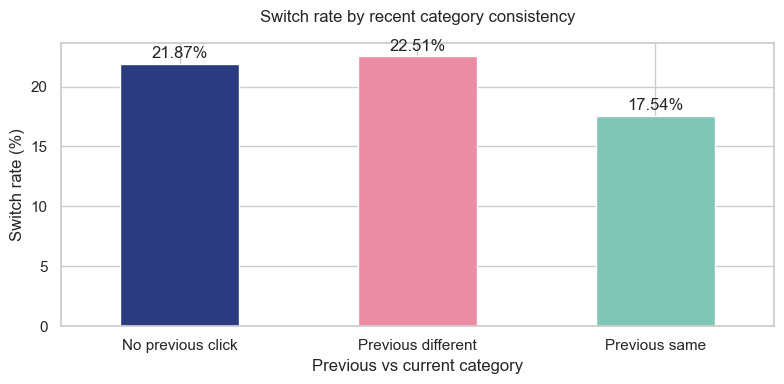

In [14]:
history_labels = {-1: "No previous click", 0: "Previous different", 1: "Previous same"}
consistency_rates = train_df.groupby("same_category_prev")["switch_category"].agg(
    ["size", "mean"]
).rename(index=history_labels)
ax = (100 * consistency_rates["mean"]).plot.bar(rot=0, color = ["#2C3A80", "#EB8BA4", "#7FC7B4"], figsize=(8, 4))
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=2)
ax.set_title("Switch rate by recent category consistency", pad=15)
ax.set(xlabel="Previous vs current category", ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

Switching is 22.51% after a different category, 17.54% after the same category, and
21.87% on first clicks. Recent consistency may help; the model comparison will test
whether it adds value beyond current information.

### 5.5 Switch rate by category visit count

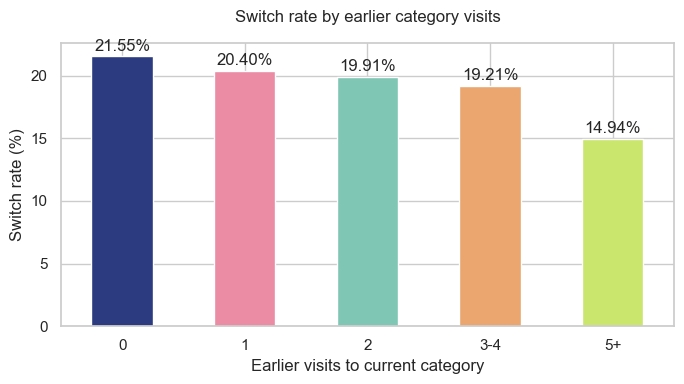

In [15]:
visit_groups = pd.cut(
    train_df["category_visit_count"], bins=[-1, 0, 1, 2, 4, np.inf],
    labels=["0", "1", "2", "3-4", "5+"]
)
visit_rates = train_df.groupby(visit_groups, observed=True)["switch_category"].agg(
    ["size", "mean"]
)
ax = (100 * visit_rates["mean"]).plot.bar(rot=0, color = ["#2C3A80", "#EB8BA4", "#7FC7B4", "#EBA56F", "#CAE66D"], figsize=(7, 4))
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=2)
ax.set_title("Switch rate by earlier category visits", pad=15)
ax.set(xlabel="Earlier visits to current category", ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

Switching falls from 21.55% with no earlier category visit to 14.94% with five or more.
Repeated interest may help prediction, but it overlaps with session position.

### 5.6 Previous-to-current category transition

Current category,Trousers,Skirts,Blouses,Sale
Previous category,,,,
Trousers,24312,2102,2099,1282
Skirts,1297,17700,1997,1026
Blouses,1397,1106,18536,1724
Sale,1008,933,1011,19774


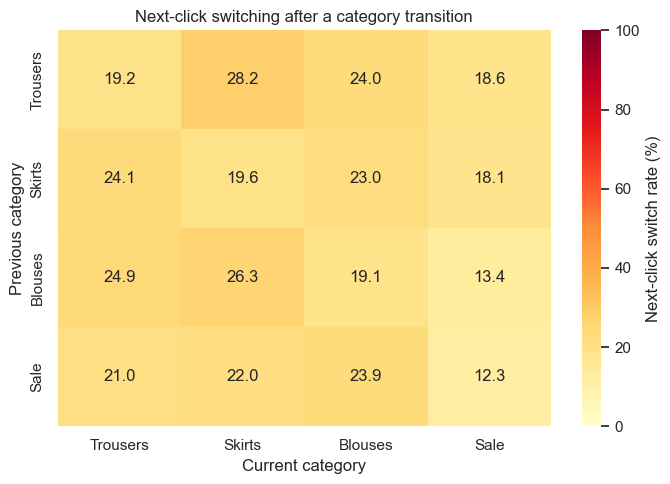

In [16]:
past_clicks = train_df[train_df["prev_category"] != 0]
transition_rates = past_clicks.pivot_table(
    index="prev_category", columns="page 1 (main category)",
    values="switch_category", aggfunc="mean"
).rename(index=category_names, columns=category_names)
transition_counts = past_clicks.pivot_table(
    index="prev_category", columns="page 1 (main category)",
    values="switch_category", aggfunc="size"
).rename(index=category_names, columns=category_names)
display(transition_counts.rename_axis(index="Previous category", columns="Current category"))
plt.figure(figsize=(7, 5))
sns.heatmap(100 * transition_rates, annot=True, fmt=".1f", cmap="YlOrRd",
            vmin=0, vmax=100, cbar_kws={"label": "Next-click switch rate (%)"})
plt.title("Next-click switching after a category transition")
plt.xlabel("Current category")
plt.ylabel("Previous category")
plt.tight_layout()
plt.show()

For current Skirts, the next-click switch rate is 28.2% after Trousers and 22.0%
after Sale. This supports testing `prev_category` alongside recent consistency.
First clicks are excluded; each transition has at least 933 observations.

### 5.7 Price and switching

,median,mean
switch_category,,
Stay,43.0,43.65
Switch,43.0,44.25


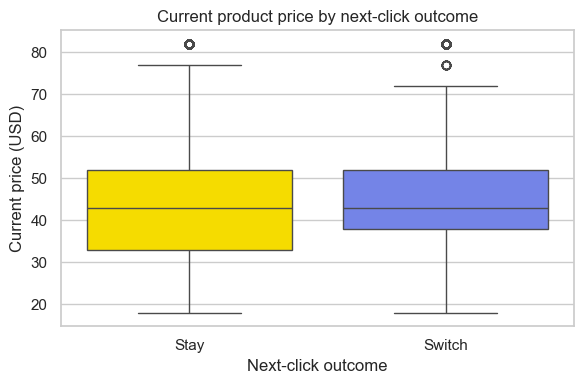

In [17]:
price_summary = train_df.groupby("switch_category")["price"].agg(["median", "mean"])
display(price_summary.rename(index={0: "Stay", 1: "Switch"}).round(2))
plt.figure(figsize=(6, 4))
sns.boxplot(data=train_df, x="switch_category", y="price", order=[0, 1], hue="switch_category", palette={0: "#F5DC00", 1: "#7484E7"}, saturation=1, legend=False)
plt.xticks([0, 1], ["Stay", "Switch"])
plt.title("Current product price by next-click outcome")
plt.xlabel("Next-click outcome")
plt.ylabel("Current price (USD)")
plt.tight_layout()
plt.show()

Both groups have a median price of $43, and their distributions overlap strongly.
Price alone does not clearly separate Stay and Switch. Keep it in the specified
current feature set to evaluate it alongside other inputs.

### 5.8 Catalogue page and switching

,Clicks,Switch rate
page,,
1,63833,0.178
2,28181,0.179
3,13014,0.219
4,5809,0.255
5,1654,0.282


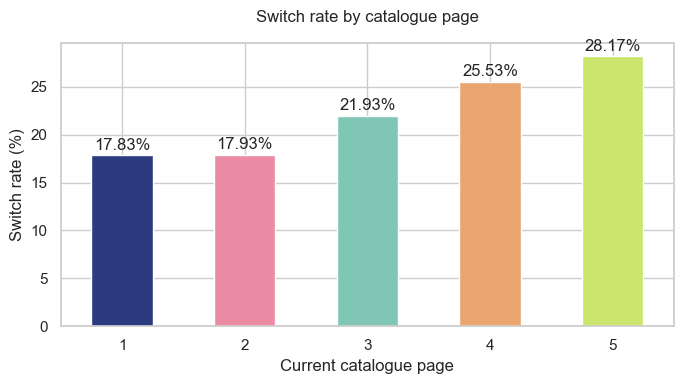

In [18]:
page_rates = train_df.groupby("page")["switch_category"].agg(["size", "mean"])
display(page_rates.rename(columns={"size": "Clicks", "mean": "Switch rate"}).round(3))
ax = (100 * page_rates["mean"]).plot.bar(rot=0, color = ["#2C3A80", "#EB8BA4", "#7FC7B4", "#EBA56F", "#CAE66D"], figsize=(7, 4))
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=2)
ax.set_title("Switch rate by catalogue page", pad=15)
ax.set(xlabel="Current catalogue page", ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

The switch rate rises from 17.83% on page 1 to
28.17% on page 5. Page 5 has only 1,654 observations,
compared with 63,833 on page 1. Retain catalogue page, while recognizing
that these pages may contain different categories and products.

## 6. Feature selection

Experiment A uses Current information. Experiment B adds exactly three history
features. 

In [19]:
current_features = [
    "page 1 (main category)", "order", "price", "colour",
    "location", "model photography", "page"
]
current_history_features = current_features + [
    "prev_category", "same_category_prev", "category_visit_count"
]

current_categorical = [
    "page 1 (main category)", "colour", "location", "model photography"
]
current_numerical = ["order", "price", "page"]
history_categorical = current_categorical + ["prev_category", "same_category_prev"]
history_numerical = current_numerical + ["category_visit_count"]

Treat category codes as categories, including the three states of `same_category_prev`.
Treat `order`, `price`, `page`, and the visit count as numerical.

| Excluded column | Reason |
| --- | --- |
| `year` | Constant |
| `month`, `day` | Outside this version's behavioral hypothesis |
| `country` | Outside the specified current browsing feature set |
| `session ID` | Identifier used for grouping only |
| `page 2 (clothing model)` | Many product IDs, overlapping with product attributes |
| `price 2` | Price comparison with the category average |
| `next_category` | Future information used to create the target |
| `switch_category` | The target itself |

In [20]:
X_train_current = train_df[current_features]
X_test_current = test_df[current_features]
X_train_history = train_df[current_history_features]
X_test_history = test_df[current_history_features]
y_train = train_df["switch_category"]
y_test = test_df["switch_category"]

print("Current features:", len(current_features))
print("Current + history features:", len(current_history_features))

Current features: 7
Current + history features: 10


## 7. Model development
Phần này bắt đầu giai đoạn xây dựng mô hình. Sử dụng đúng hai feature set đã được xác định ở phần trước là `Current` và `Current + History`, đồng thời giữ nguyên train/test split theo `session ID`.  

Mục tiêu của phần modeling không phải thử càng nhiều model càng tốt, mà là so sánh một số model đại diện cho các cách học khác nhau:  
- Logistic Regression làm linear baseline.
- Decision Tree để quan sát các decision rules dễ diễn giải.
- Random Forest để kiểm tra các quan hệ phi tuyến và interaction giữa features.
- SVM để kiểm tra liệu một decision boundary khác có cải thiện khả năng phát hiện `Switch` hay không.  

Trong toàn bộ phần này:  
- chỉ train model trên training set;
- không thay đổi test set giữa các model;
- không lựa chọn model dựa riêng vào Accuracy;
- ưu tiên `Switch F1`, sau đó xem thêm Precision, Recall, Macro F1 và ROC-AUC;
- lưu lại kết quả của từng model để phần 12 có thể tổng hợp vào một bảng duy nhất.

### 7.1 Preprocessing
Xác định rõ categorical features và numerical features cho từng feature set.  
Với categorical features, sử dụng: `OneHotEncoder(handle_unknown="ignore")`
để tránh lỗi khi test set có category không xuất hiện trong train set.

Với numerical features:
- Logistic Regression và SVM nên được scale bằng StandardScaler;
- Decision Tree và Random Forest không bắt buộc scaling.

Nên sử dụng `ColumnTransformer` kết hợp với `Pipeline` để đảm bảo preprocessing chỉ được fit trên training data và tránh train-test leakage.

Không tạo một preprocessing framework quá tổng quát. Chỉ cần tạo preprocessing phù hợp với từng nhóm model nếu cần.

Sau khi định nghĩa preprocessing, kiểm tra lại:
- feature nào đang được xem là categorical;
- feature nào là numerical;
- không có `session ID`, `next_category`, `switch_category` trong input model.

In [21]:
RANDOM_STATE = 42
excluded_cols = {"session ID", "next_category", "switch_category"}
assert excluded_cols.isdisjoint(current_features)
assert excluded_cols.isdisjoint(current_history_features)

assert train_df[current_features].isna().sum().sum() == 0
assert train_df[current_history_features].isna().sum().sum() == 0
assert test_df[current_features].isna().sum().sum() == 0
assert test_df[current_history_features].isna().sum().sum() == 0

print("Current categorical:", current_categorical)
print("Current numerical:", current_numerical)
print("History categorical:", history_categorical)
print("History numerical:", history_numerical)

linear_current = ColumnTransformer([
    ("num", StandardScaler(), current_numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), current_categorical)
])

linear_history = ColumnTransformer([
    ("num", StandardScaler(), history_numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), history_categorical)
])

tree_current = ColumnTransformer([
    ("num", "passthrough", current_numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), current_categorical)
])

tree_history = ColumnTransformer([
    ("num", "passthrough", history_numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), history_categorical)
])



Current categorical: ['page 1 (main category)', 'colour', 'location', 'model photography']
Current numerical: ['order', 'price', 'page']
History categorical: ['page 1 (main category)', 'colour', 'location', 'model photography', 'prev_category', 'same_category_prev']
History numerical: ['order', 'price', 'page', 'category_visit_count']


### 7.2 Evaluation metrics
Vì `Switch = 1` là minority class và là class quan trọng về mặt business, không sử dụng Accuracy làm metric chính.
Sử dụng:
- `Switch F1` làm metric chính;
- `Switch precision`;
- `Switch recall`;
- `Macro F1`;
- `ROC-AUC`;
- `Accuracy` chỉ để tham khảo.

Khi giải thích kết quả:
- Precision trả lời: trong các trường hợp model dự đoán `Switch`, bao nhiêu trường hợp thực sự switch?
- Recall trả lời: trong tất cả trường hợp thực sự `Switch`, model phát hiện được bao nhiêu?
- F1 cân bằng giữa Precision và Recall.

Đối với project này, nếu Accuracy giảm nhưng Switch F1 và Recall tăng rõ rệt thì không được kết luận model tệ hơn.

Chuẩn bị một cách lưu metric thống nhất cho các model, ví dụ một list các dictionary để phần 12 tạo comparison table.

In [22]:
results = []

def evaluate_predictions(model_name, feature_set, y_true, y_pred, y_prob):
    metrics = {
        "Model": model_name,
        "Features": feature_set,
        "Switch Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Switch Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Switch F1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred)
    }

    results.append(metrics)
    return metrics

### 7.3 Always-Stay baseline
Tạo baseline đơn giản nhất:  
Dự đoán tất cả observations là `Stay = 0`.

Tính đầy đủ:
- Accuracy
- Switch precision
- Switch recall
- Switch F1
- Macro F1
- ROC-AUC nếu phù hợp

Mục đích của baseline là chứng minh rằng Accuracy cao không đồng nghĩa với model hữu ích.

Sau khi chạy baseline, cần chỉ ra:
- baseline có thể đạt Accuracy cao vì Stay là majority class;
- nhưng Switch Recall và Switch F1 bằng 0;
- do đó một model ML chỉ thực sự hữu ích nếu nó phát hiện được ít nhất một phần Switch observations.

Baseline này sẽ là reference point cho tất cả model phía sau.

In [23]:

stay_pred = np.zeros(len(y_test), dtype=int)
stay_prob = np.zeros(len(y_test), dtype=float)

baseline_result = evaluate_predictions(
    model_name="Always-Stay baseline",
    feature_set="None",
    y_true=y_test,
    y_pred=stay_pred,
    y_prob=stay_prob
)

display(pd.DataFrame([baseline_result]).round(4))

,Model,Features,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC,Accuracy
0,Always-Stay baseline,None,0.0,0.0,0.0,0.4497,0.5,0.8173


## 8. Logistic Regression
Sử dụng Logistic Regression để tạo một linear baseline và kiểm tra tác động của class imbalance cũng như historical features.

### 8.1 Logistic Regression baseline
Train Logistic Regression đầu tiên với:
- feature set: `Current`
- `class_weight=None`

Sử dụng pipeline gồm preprocessing + Logistic Regression.

Sau khi predict test set, tính toàn bộ metrics đã định nghĩa ở 7.2.

Đặc biệt quan sát:
- model có dự đoán được class Switch hay không;
- Switch Recall và Switch F1 có gần 0 không;
- Accuracy có cao chủ yếu vì model dự đoán Stay hay không.

Nếu model gần như chỉ dự đoán Stay, cần giải thích rằng đây là ảnh hưởng của class imbalance chứ không phải model đã hoạt động tốt.

In [24]:

logreg_baseline = Pipeline([
    ("preprocessor", linear_current),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight=None,
        random_state=RANDOM_STATE
    ))
])

logreg_baseline.fit(X_train_current, y_train)

y_pred = logreg_baseline.predict(X_test_current)
y_prob = logreg_baseline.predict_proba(X_test_current)[:, 1]

logreg_baseline_result = evaluate_predictions(
    model_name="Logistic Regression",
    feature_set="Current",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob
)

display(pd.DataFrame([logreg_baseline_result]).round(4))

pred_counts = pd.Series(y_pred).value_counts().sort_index()

print("Predicted Stay:", pred_counts.get(0, 0))
print("Predicted Switch:", pred_counts.get(1, 0))
print(f"Predicted Switch rate: {(y_pred == 1).mean():.2%}")

,Model,Features,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC,Accuracy
0,Logistic Regression,Current,0.0,0.0,0.0,0.4497,0.6159,0.8173


Predicted Stay: 28957
Predicted Switch: 0
Predicted Switch rate: 0.00%


### 8.2 Handle class imbalance
Train lại Logistic Regression với cùng feature set `Current`, nhưng sử dụng: `class_weight="balanced"`

Giữ các thiết lập còn lại tương đương model trước để comparison công bằng.

So sánh trực tiếp:
- Logistic Regression bình thường
- Balanced Logistic Regression

Tập trung vào sự thay đổi của:
- Switch precision
- Switch recall
- Switch F1
- Accuracy

Mục tiêu là kiểm tra liệu xử lý class imbalance có giúp model thực sự phát hiện Switch hay không.  
Nếu Recall tăng nhưng Accuracy giảm, cần giải thích đây là trade-off hợp lý.

In [25]:
logreg_current = Pipeline([
    ("preprocessor", linear_current),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])
logreg_current.fit(X_train_current, y_train)

y_pred_bal = logreg_current.predict(X_test_current)
y_prob_bal = logreg_current.predict_proba(X_test_current)[:, 1]

logreg_balanced_result = evaluate_predictions(
    model_name="Balanced Logistic Regression",
    feature_set="Current",
    y_true=y_test,
    y_pred=y_pred_bal,
    y_prob=y_prob_bal
)

display(pd.DataFrame([logreg_balanced_result]).round(4))

,Model,Features,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC,Accuracy
0,Balanced Logistic Regression,Current,0.2324,0.5961,0.3344,0.5064,0.6162,0.5664


In [26]:
# So sánh các kết quả của Logistic Regression trước và sau khi cân bằng lớp
comparison_logreg = pd.DataFrame([
    logreg_baseline_result,
    logreg_balanced_result
])[
    ["Model", "Accuracy", "Switch Precision", "Switch Recall", "Switch F1", "Macro F1", "ROC-AUC"]
]

display(comparison_logreg.round(4))

print("Change after class balancing:")
print(f"Accuracy: {logreg_balanced_result['Accuracy'] - logreg_baseline_result['Accuracy']:+.4f}")
print(f"Switch Precision: {logreg_balanced_result['Switch Precision'] - logreg_baseline_result['Switch Precision']:+.4f}")
print(f"Switch Recall: {logreg_balanced_result['Switch Recall'] - logreg_baseline_result['Switch Recall']:+.4f}")
print(f"Switch F1: {logreg_balanced_result['Switch F1'] - logreg_baseline_result['Switch F1']:+.4f}")

,Model,Accuracy,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC
0,Logistic Regression,0.8173,0.0000,0.0000,0.0000,0.4497,0.6159
1,Balanced Logistic Regression,0.5664,0.2324,0.5961,0.3344,0.5064,0.6162


Change after class balancing:
Accuracy: -0.2509
Switch Precision: +0.2324
Switch Recall: +0.5961
Switch F1: +0.3344


### 8.3 Test historical features
Train Balanced Logistic Regression lần nữa với: `Current + History
`
Giữ nguyên:
- train/test split;
- preprocessing;
- Logistic Regression settings;
- `class_weight="balanced"`.

Chỉ thay đổi feature set.

So sánh: Balanced Logistic + Current vs Balanced Logistic + Current + History

Mục tiêu là trả lời một phần RQ2:
Historical browsing behavior có cung cấp thêm predictive value cho linear model không?

Không chỉ nhìn Accuracy. So sánh chủ yếu Switch F1 và ROC-AUC.

Nếu cải thiện rất nhỏ thì ghi rõ là cải thiện nhỏ, không phóng đại kết quả.

In [27]:
logreg_history = Pipeline([
    ("preprocessor", linear_history),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])
logreg_history.fit(X_train_history, y_train)

y_pred_hist = logreg_history.predict(X_test_history)
y_prob_hist = logreg_history.predict_proba(X_test_history)[:, 1]

logreg_history_result = evaluate_predictions(
    model_name="Balanced Logistic Regression",
    feature_set="Current + History",
    y_true=y_test,
    y_pred=y_pred_hist,
    y_prob=y_prob_hist
)

display(pd.DataFrame([logreg_history_result]).round(4))

,Model,Features,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC,Accuracy
0,Balanced Logistic Regression,Current + History,0.2335,0.6116,0.3379,0.5054,0.6242,0.5621


In [28]:
# So sánh Current vs Current + History
comparison_history = pd.DataFrame([logreg_balanced_result,logreg_history_result])[
    ["Model", "Features", "Accuracy", "Switch Precision",
     "Switch Recall", "Switch F1", "Macro F1", "ROC-AUC"]
]

display(comparison_history.round(4))
print("Effect of adding historical features:")
print(f"Switch F1: {logreg_history_result['Switch F1'] - logreg_balanced_result['Switch F1']:+.4f}")
print(f"ROC-AUC:   {logreg_history_result['ROC-AUC'] - logreg_balanced_result['ROC-AUC']:+.4f}")
print(f"Recall:    {logreg_history_result['Switch Recall'] - logreg_balanced_result['Switch Recall']:+.4f}")
print(f"Accuracy:  {logreg_history_result['Accuracy'] - logreg_balanced_result['Accuracy']:+.4f}")

,Model,Features,Accuracy,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC
0,Balanced Logistic Regression,Current,0.5664,0.2324,0.5961,0.3344,0.5064,0.6162
1,Balanced Logistic Regression,Current + History,0.5621,0.2335,0.6116,0.3379,0.5054,0.6242


Effect of adding historical features:
Switch F1: +0.0035
ROC-AUC:   +0.0080
Recall:    +0.0155
Accuracy:  -0.0043


Historical features provide a small predictive improvement for the linear model. Switch F1 increases by 0.0035 and ROC-AUC by 0.0080, while recall improves by 0.0155. The gain is therefore positive but modest. The slight drop in Accuracy is acceptable because the project prioritizes detecting the minority Switch class rather than maximizing overall Accuracy.

## 9. Tree-based models
Phần này kiểm tra các model có khả năng học nonlinear relationships.

### 9.1 Decision Tree

Train Decision Tree với `Current + History`.

Nên chọn các parameter giúp cây không quá sâu, ví dụ giới hạn `max_depth`, `min_samples_split` hoặc `min_samples_leaf` ở mức hợp lý.

Không cần tuning mạnh ở bước này.

Sau khi train:
- tính cùng bộ metrics;
- lưu kết quả vào danh sách kết quả chung;
- visualize cây bằng `plot_tree()`.

Nếu full tree quá lớn, chỉ hiển thị một số tầng đầu, ví dụ 2–3 levels.

Mục tiêu của visualization là xem model sử dụng những rule nào để phân biệt Stay và Switch.

Khi nhận xét, tập trung vào:
- feature nào xuất hiện gần root;
- các threshold/rule lớn có ý nghĩa gì;
- không cố đọc toàn bộ cây.

,Model,Features,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC,Accuracy
0,Decision Tree,Current,0.2255,0.687,0.3395,0.476,0.6192,0.5116


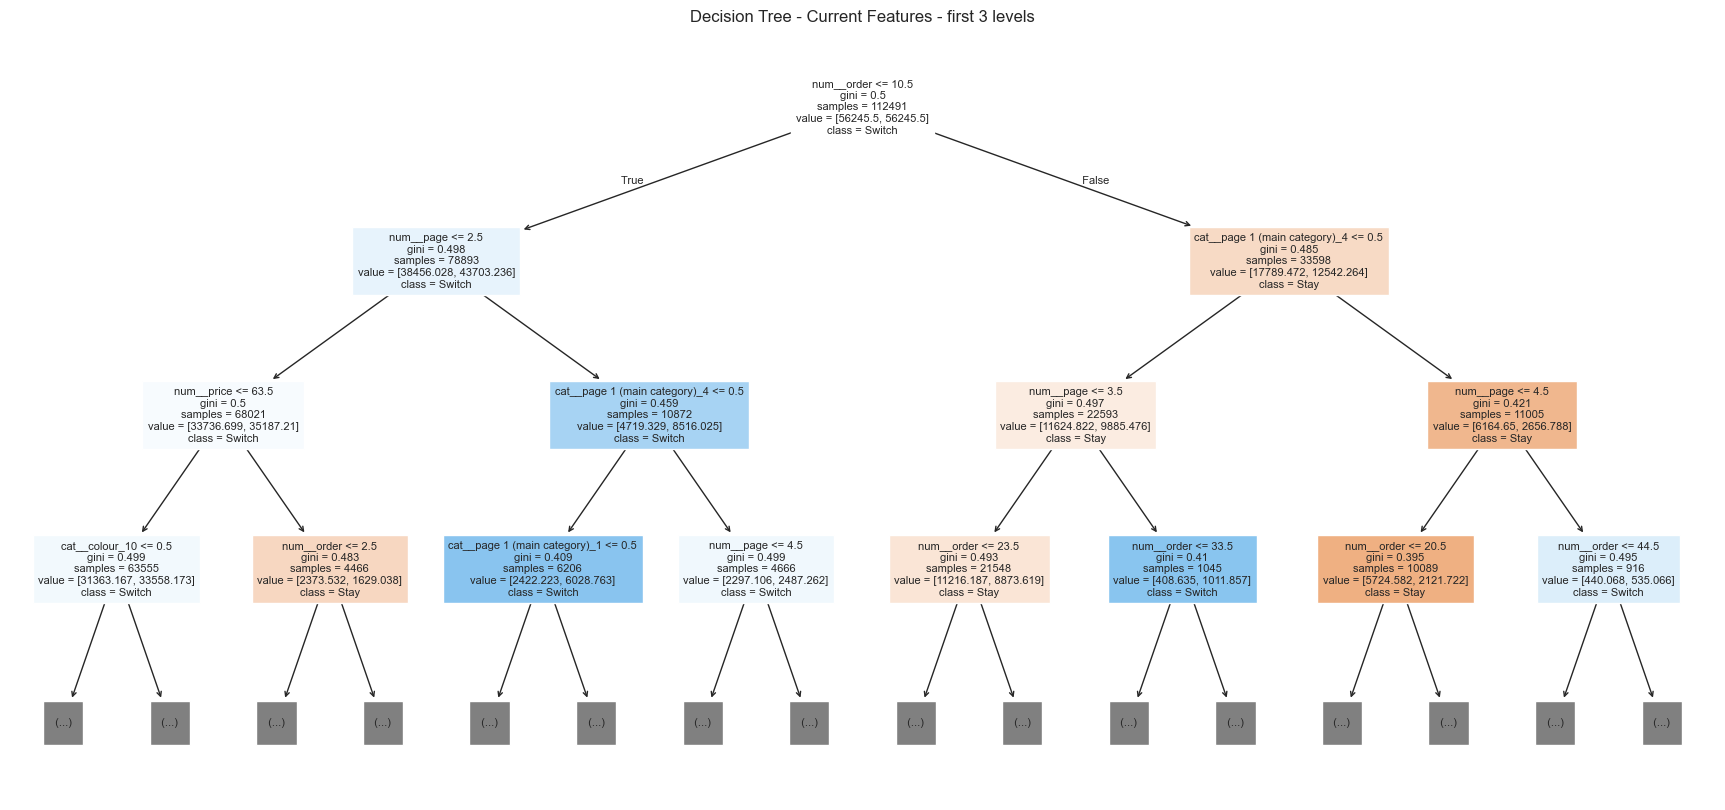

In [ ]:

dt_current = Pipeline([
    ("preprocessor", tree_current),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

dt_current.fit(X_train_current, y_train)

y_pred_dt_current = dt_current.predict(X_test_current)
y_prob_dt_current = dt_current.predict_proba(X_test_current)[:, 1]

dt_current_result = evaluate_predictions(
    model_name="Decision Tree",
    feature_set="Current",
    y_true=y_test,
    y_pred=y_pred_dt_current,
    y_prob=y_prob_dt_current
)

display(pd.DataFrame([dt_current_result]).round(4))

feature_names = dt_current.named_steps["preprocessor"].get_feature_names_out()
tree_model = dt_current.named_steps["model"]

plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Stay", "Switch"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree - Current Features - first 3 levels")
plt.show()

,Model,Features,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC,Accuracy
0,Decision Tree,Current + History,0.2285,0.69,0.3433,0.4811,0.6265,0.5176


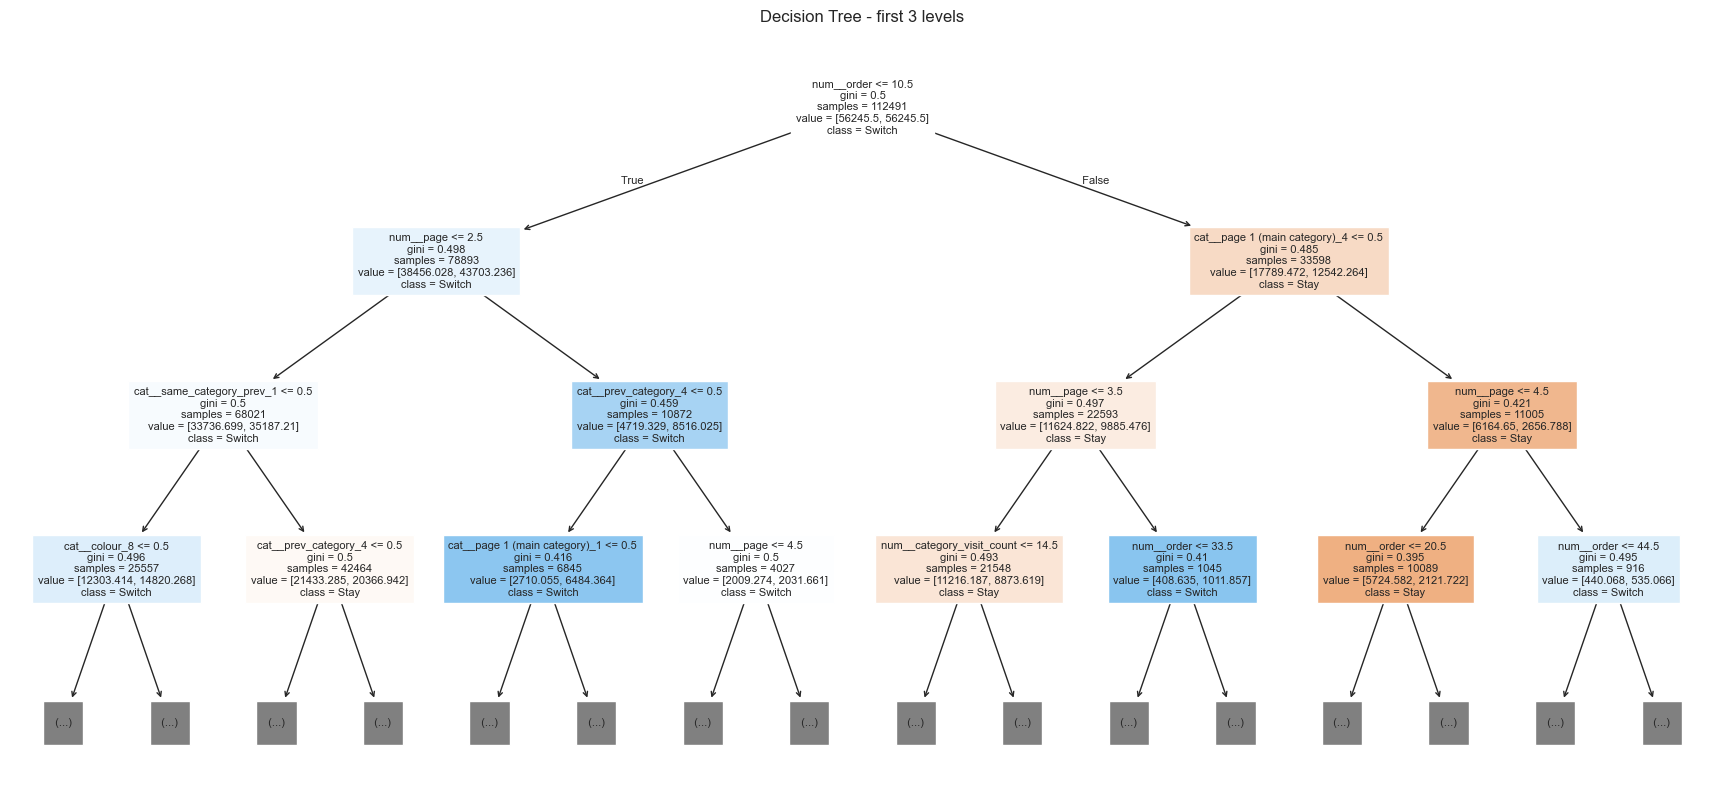

In [29]:
dt_history = Pipeline([
    ("preprocessor", tree_history),
    ("model", DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE))
])
dt_history.fit(X_train_history, y_train)

y_pred_dt = dt_history.predict(X_test_history)
y_prob_dt = dt_history.predict_proba(X_test_history)[:, 1]

dt_result = evaluate_predictions(
    model_name="Decision Tree",
    feature_set="Current + History",
    y_true=y_test,
    y_pred=y_pred_dt,
    y_prob=y_prob_dt
)

display(pd.DataFrame([dt_result]).round(4))

feature_names = dt_history.named_steps["preprocessor"].get_feature_names_out()
tree_model = dt_history.named_steps["model"]

plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Stay", "Switch"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree - first 3 levels")
plt.show()

**Interpretation:**  
The first split is based on **order ≤ 10.5**, showing that click position within the session is the strongest early rule. For earlier clicks, the tree then uses **page ≤ 2.5**, followed by historical features such as **same_category_prev** and **prev_category**. For later clicks, the model also uses **current main category** and **category_visit_count ≤ 14.5**. Overall, both current browsing context and recent history appear in the upper levels of the tree, suggesting that both contribute to distinguishing **Stay** from **Switch**.

### 9.2 Random Forest with Current
Train Random Forest chỉ với feature `set Current`.

Đây là controlled baseline cho experiment về historical features.

Chọn một bộ hyperparameters ban đầu hợp lý và chưa tuning, ví dụ các parameter như:
- `n_estimators`;
- `max_depth`;
- `min_samples_split`;
- `min_samples_leaf`;
- `class_weight`;
- `random_state`.

Lưu chính xác bộ parameter này vì mục 9.3 phải dùng y hệt.

Sau khi predict:
- tính đầy đủ metrics;
- lưu kết quả.

In [30]:

rf_params = {
    "n_estimators": 200,
    "max_depth": 12,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

rf_current = Pipeline([
    ("preprocessor", tree_current),
    ("model", RandomForestClassifier(**rf_params))
])

rf_current.fit(X_train_current, y_train)

y_pred_rf_current = rf_current.predict(X_test_current)
y_prob_rf_current = rf_current.predict_proba(X_test_current)[:, 1]

rf_current_result = evaluate_predictions(
    model_name="Random Forest",
    feature_set="Current",
    y_true=y_test,
    y_pred=y_pred_rf_current,
    y_prob=y_prob_rf_current
)

display(pd.DataFrame([rf_current_result]).round(4))

,Model,Features,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC,Accuracy
0,Random Forest,Current,0.2555,0.6035,0.359,0.5374,0.6483,0.6062


### 9.3 Random Forest with Current + History

Train Random Forest với `Current + History`.

Quan trọng:

Sử dụng chính xác cùng hyperparameters với Random Forest ở 9.2.

Chỉ thay đổi feature set.

So sánh: Random Forest + Current vs Random Forest + Current + History

Đây là experiment quan trọng nhất để trả lời RQ2 vì nó cô lập tác động của historical features.

Nếu Switch F1 tăng:
- tính mức tăng tuyệt đối;
- đánh giá mức tăng là nhỏ hay đáng kể.

Không dùng feature importance để thay thế comparison này.

In [31]:

rf_history = Pipeline([
    ("preprocessor", tree_history),
    ("model", RandomForestClassifier(**rf_params))
])

rf_history.fit(X_train_history, y_train)

y_pred_rf_history = rf_history.predict(X_test_history)
y_prob_rf_history = rf_history.predict_proba(X_test_history)[:, 1]

rf_history_result = evaluate_predictions(
    model_name="Random Forest",
    feature_set="Current + History",
    y_true=y_test,
    y_pred=y_pred_rf_history,
    y_prob=y_prob_rf_history
)

display(pd.DataFrame([rf_history_result]).round(4))

,Model,Features,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC,Accuracy
0,Random Forest,Current + History,0.2646,0.6001,0.3673,0.549,0.6621,0.6222


In [32]:
# So sánh các kết quả của Random Forest với Current vs Current + History
rf_comparison = pd.DataFrame([
    rf_current_result,
    rf_history_result
])[
    ["Model", "Features", "Accuracy", "Switch Precision",
     "Switch Recall", "Switch F1", "Macro F1", "ROC-AUC"]
]

display(rf_comparison.round(4))
f1_gain = rf_history_result["Switch F1"] - rf_current_result["Switch F1"]
auc_gain = rf_history_result["ROC-AUC"] - rf_current_result["ROC-AUC"]

print(f"Switch F1 change: {f1_gain:+.4f}")
print(f"ROC-AUC change:   {auc_gain:+.4f}")

,Model,Features,Accuracy,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC
0,Random Forest,Current,0.6062,0.2555,0.6035,0.3590,0.5374,0.6483
1,Random Forest,Current + History,0.6222,0.2646,0.6001,0.3673,0.5490,0.6621


Switch F1 change: +0.0083
ROC-AUC change:   +0.0138


**Interpretation:**  
Adding historical features gives a **small but consistent improvement** for Random Forest. Switch F1 increases from **0.3590 to 0.3673** (**+0.0083**), while ROC-AUC rises from **0.6483 to 0.6621** (**+0.0138**). Accuracy and Macro F1 also improve slightly, although Switch Recall decreases marginally from **0.6035 to 0.6001**. Overall, historical browsing behavior adds some predictive value, but the improvement is modest rather than substantial.

## 10. Support Vector Machine
Sử dụng SVM như một model bổ sung để kiểm tra một loại decision boundary khác so với Logistic Regression và tree-based models.

Do dataset tương đối lớn, cần chú ý runtime và memory.

### 10.1 SVM model
Bắt đầu với `Current + History`.
Ưu tiên thử:

In [33]:
#SVC( kernel="rbf", class_weight="balanced", probability=True, random_state=42)

SVM bắt buộc phải scale numerical features, nên sử dụng pipeline:  
preprocessing  
→ scaling  
→ SVM  

Không thử nhiều kernel ngay từ đầu.  
Nếu RBF SVM quá chậm hoặc không khả thi với toàn bộ training set:
- ghi nhận runtime problem;
- cân nhắc `LinearSVC` như một phương án nhẹ hơn;
- không tự ý lấy random subset nếu chưa thống nhất với nhóm vì điều đó làm comparison với các model khác kém công bằng.

In [34]:
from sklearn.svm import LinearSVC

svm_history = Pipeline([
    ("preprocessor", linear_history),
    ("model", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

svm_history.fit(X_train_history, y_train)
y_pred_svm = svm_history.predict(X_test_history)
y_score_svm = svm_history.decision_function(X_test_history)

svm_result = {
    "Model": "Linear SVM",
    "Features": "Current + History",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Switch Precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "Switch Recall": recall_score(y_test, y_pred_svm, zero_division=0),
    "Switch F1": f1_score(y_test, y_pred_svm, zero_division=0),
    "Macro F1": f1_score(y_test, y_pred_svm, average="macro", zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_score_svm)
}
results.append(svm_result)

display(pd.DataFrame([svm_result]).round(4))

,Model,Features,Accuracy,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC
0,Linear SVM,Current + History,0.5608,0.2333,0.6139,0.3381,0.5047,0.624


RBF SVM was computationally expensive on the full training set, so LinearSVC was used as a scalable SVM alternative.

### 10.2 SVM evaluation
Sau khi train, tính cùng bộ metrics như các model trước.  
So sánh SVM với:
- Balanced Logistic + History;
- Decision Tree + History;
- Random Forest + History.  

Mục tiêu là xem nonlinear SVM có tạo improvement đủ đáng kể hay không.   
Không cần tạo SVM Current trừ khi nhóm muốn nghiên cứu riêng ảnh hưởng của history đối với SVM.  
Nếu SVM không tốt hơn Random Forest, vẫn giữ kết quả và giải thích bình thường. Không cần tuning chỉ vì SVM là model mới học trên lớp.

In [35]:
svm_comparison = pd.DataFrame([
    logreg_history_result,
    dt_result,
    rf_history_result,
    svm_result
])[
    ["Model", "Features", "Accuracy", "Switch Precision",
     "Switch Recall", "Switch F1", "Macro F1", "ROC-AUC"]
]

display(
    svm_comparison
    .sort_values("Switch F1", ascending=False)
    .round(4)
)

,Model,Features,Accuracy,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC
2,Random Forest,Current + History,0.6222,0.2646,0.6001,0.3673,0.5490,0.6621
1,Decision Tree,Current + History,0.5176,0.2285,0.6900,0.3433,0.4811,0.6265
3,Linear SVM,Current + History,0.5608,0.2333,0.6139,0.3381,0.5047,0.6240
0,Balanced Logistic Regression,Current + History,0.5621,0.2335,0.6116,0.3379,0.5054,0.6242


**SVM interpretation:**  
Linear SVM achieves a **Switch F1 of 0.3381**, with **Recall = 0.6139** and **ROC-AUC = 0.6240**. Its performance is very close to Balanced Logistic Regression, but it is clearly below Random Forest, which reaches a higher **Switch F1 (0.3673)** and **ROC-AUC (0.6621)**. Therefore, Linear SVM does not provide a meaningful improvement over the stronger tree-based model.

## 11. Model tuning
Chỉ tuning model có performance tốt nhất hoặc có tiềm năng rõ nhất sau các experiment ở trên.  
Không tuning tất cả model.

### 11.1 Define tuning objective
Trước khi tuning, chọn candidate model dựa trên kết quả validation/training experiment và lý do rõ ràng.

Objective chính:  
Tăng Switch F1 mà không làm model trở nên phức tạp không cần thiết.  

Nếu model được chọn là Random Forest, ưu tiên tune các parameter có ý nghĩa rõ ràng.  
Nếu SVM unexpectedly tốt hơn, có thể chọn SVM làm candidate.  

Không tuning theo Accuracy.  

Nếu sử dụng cross-validation trong tuning, phải dùng group-aware cross-validation theo `session ID`, để click của cùng session không nằm ở nhiều folds khác nhau.

In [36]:
# 11.1 Select tuning candidate by highest Switch F1

model_results = pd.DataFrame([
    logreg_history_result,
    dt_result,
    rf_history_result,
    svm_result
])

candidate_row = model_results.loc[model_results["Switch F1"].idxmax()]

candidate_model = candidate_row["Model"]
candidate_f1 = candidate_row["Switch F1"]
candidate_auc = candidate_row["ROC-AUC"]

print("Selected tuning candidate:", candidate_model)
print(f"Switch F1: {candidate_f1:.4f}")
print(f"ROC-AUC: {candidate_auc:.4f}")

Selected tuning candidate: Random Forest
Switch F1: 0.3673
ROC-AUC: 0.6621


The tuning candidate is selected automatically as the model with the highest **Switch F1** among the `Current + History` models. Accuracy is not used for model selection.

### 11.2 {Best_model_name} hyperparameters
Đổi `{Best_model_name}` thành tên model thực sự được chọn.

Liệt kê ngắn các hyperparameters sẽ tune và giải thích tác dụng.

Ví dụ nếu là Random Forest:
- `n_estimators`: số lượng cây;
- `max_depth`: độ sâu tối đa;
- `min_samples_split`: số mẫu tối thiểu để split;
- `min_samples_leaf`: số mẫu tối thiểu ở leaf;
- `max_features`: số features được cân nhắc ở mỗi split;
- `class_weight`: cách xử lý imbalance.

Không tạo search space quá lớn.

Ưu tiên 2–4 giá trị hợp lý cho mỗi parameter quan trọng.

Nếu dùng GridSearchCV hoặc RandomizedSearchCV:
- scoring phải dựa trên F1 của `Switch = 1`;
- CV phải giữ grouping theo session.

In [39]:
# 11.2 Random Forest tuning with RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import make_scorer, f1_score

switch_f1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0
)

groups = train_df["session ID"]
group_cv = GroupKFold(n_splits=5)

rf_tuning = Pipeline([
    ("preprocessor", tree_history),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

param_distributions = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 10,12,16],
    "model__min_samples_split": [5, 10, 12],
    "model__min_samples_leaf": [2, 5],
    "model__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_distributions,
    n_iter=10,
    scoring=switch_f1_scorer,
    cv=group_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

random_search.fit(
    X_train_history,
    y_train,
    groups=groups
)

print("Best parameters:")
print(random_search.best_params_)

print(f"\nBest CV Switch F1: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 10}

Best CV Switch F1: 0.3694


### 11.3 Best parameters
Sau khi tuning:
- in ra best parameters;
- in best cross-validation score;
- có thể show một bảng nhỏ top configurations nếu cần.

Không cần hiển thị toàn bộ hàng trăm combinations.

Viết nhận xét:
- parameter nào được chọn;
- tuned score có cải thiện đáng kể so với base model không;
- có dấu hiệu model trở nên quá phức tạp không.

In [ ]:

print("Best parameters:")
print(random_search.best_params_)

print(f"\nBest CV Switch F1: {random_search.best_score_:.4f}")

cv_results = pd.DataFrame(random_search.cv_results_)

top_configs = cv_results[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "param_model__max_features"
    ]
].sort_values("rank_test_score").head(5)

display(top_configs.round(4))

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 10}

Best CV Switch F1: 0.3694


,rank_test_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features
7,1,0.3694,0.0087,100,10,5,5,log2
4,2,0.3690,0.0085,200,10,10,5,sqrt
6,3,0.3688,0.0098,200,12,10,5,log2
9,4,0.3652,0.0077,100,8,12,5,sqrt
8,5,0.3649,0.0072,100,8,5,2,sqrt


**Interpretation:**  
The best Random Forest uses **100 trees**, `max_depth=10`, `min_samples_split=5`, `min_samples_leaf=5`, and `max_features="log2"`. The best cross-validation Switch F1 is **0.3694**, only slightly higher than the base Random Forest Switch F1 of **0.3673**. Therefore, tuning provides only a very small improvement. The selected depth and leaf constraints remain moderate, so there is no clear indication that the tuned model became unnecessarily complex.

### 11.4 Retrain tuned model
Dùng best parameters để train lại model trên toàn bộ training set.

Sau đó chỉ đánh giá test set một lần ở configuration cuối.

Lưu:
- final predictions;
- predicted probabilities nếu có;
- toàn bộ metrics.

Model này sẽ được chuyển sang phần 12 và 13 để đánh giá cuối cùng.

In [ ]:

final_rf = Pipeline([
    ("preprocessor", tree_history),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=5,
        max_features="log2",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

final_rf.fit(X_train_history, y_train)

final_pred = final_rf.predict(X_test_history)
final_prob = final_rf.predict_proba(X_test_history)[:, 1]

final_result = {
    "Model": "Tuned Random Forest",
    "Features": "Current + History",
    "Accuracy": accuracy_score(y_test, final_pred),
    "Switch Precision": precision_score(y_test, final_pred, pos_label=1, zero_division=0),
    "Switch Recall": recall_score(y_test, final_pred, pos_label=1, zero_division=0),
    "Switch F1": f1_score(y_test, final_pred, pos_label=1, zero_division=0),
    "Macro F1": f1_score(y_test, final_pred, average="macro", zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_prob)
}

display(pd.DataFrame([final_result]).round(4))

,Model,Features,Accuracy,Switch Precision,Switch Recall,Switch F1,Macro F1,ROC-AUC
0,Tuned Random Forest,Current + History,0.6163,0.2631,0.611,0.3679,0.5462,0.6616


**Interpretation:**  
Hyperparameter tuning produced only a marginal improvement in Switch F1, from **0.3673** to **0.3679**. Other metrics, including ROC-AUC and Macro F1, remained almost unchanged or decreased slightly. This suggests that the baseline Random Forest was already close to a suitable configuration and that further performance gains are more likely to come from threshold optimization or additional informative features rather than more extensive hyperparameter tuning.

## 12. Model evaluation and comparison
Phần này do Phương Linh tổng hợp các output từ Phương Anh.
Không train thêm model ở đây.

### 12.1 Model comparison table
Tổng hợp tất cả model vào một bảng duy nhất.

Các cột:
- Model
- Feature set
- Accuracy
- Switch precision
- Switch recall
- Switch F1
- Macro F1
- ROC-AUC

Các hàng nên gồm:
- Always Stay
- Logistic Regression
- Balanced Logistic Regression
- Balanced Logistic + History
- Decision Tree + History
- Random Forest + Current
- Random Forest + History
- SVM + History
- Tuned best model

Sort hoặc highlight theo Switch F1 nếu cần.  
Không chọn best model bằng Accuracy.

### 12.2 Compare Current vs Current + History
Tạo phần so sánh riêng để trả lời RQ2.  

Ít nhất phải so sánh:  
Balanced Logistic:  
Current vs Current + History  

và:  
Random Forest:  
Current vs Current + History  

Với mỗi model:
- ghi Switch F1 trước và sau;
- tính mức chênh lệch;
- có thể xem thêm ROC-AUC.

Sau đó nhận xét:
- history có giúp không;
- mức cải thiện lớn hay nhỏ;
- improvement có consistent trên cả linear và nonlinear model hay không.

Không dùng SVM để trả lời RQ2 nếu không có SVM Current.

### 12.3 Select best model
Chọn final model dựa trên:
1. Switch F1;
2. Precision/Recall trade-off;
3. Macro F1;
4. ROC-AUC;
5. độ phức tạp nếu các model có performance gần nhau.

Giải thích rõ vì sao chọn model đó.

Ví dụ:
- nếu Decision Tree Recall cao hơn nhưng Precision rất thấp;
- Random Forest F1 tốt hơn và cân bằng hơn;

  thì Random Forest có thể hợp lý hơn.

Không ghi đơn giản:
Random Forest has the highest accuracy, so it is the best model.

## 13. Best model analysis
Chỉ phân tích sâu model cuối cùng được chọn.

### 13.1 Classification report
In classification report của final model.

Tập trung vào class Switch = 1.

Giải thích:
- Precision;
- Recall;
- F1;
- support.

Có thể đối chiếu với Stay để chỉ ra ảnh hưởng của imbalance.

Không cần trình bày classification report cho tất cả model.

### 13.2 Confusion matrix
Vẽ confusion matrix rõ nhãn:  
Actual Stay / Actual Switch  
Predicted Stay / Predicted Switch  

Xác định:
- True Negative;
- False Positive;
- False Negative;
- True Positive.

Sau đó diễn giải hai loại lỗi quan trọng:

False Positive  
Model dự đoán user sẽ Switch nhưng thực tế họ Stay.

False Negative  
Model dự đoán user sẽ Stay nhưng thực tế họ Switch.

Tính hoặc nhắc lại:
- Recall để biết bao nhiêu actual Switch được phát hiện;
- Precision để biết prediction Switch đáng tin cậy đến đâu.

Đây sẽ là cơ sở cho phần business interpretation sau.

### 13.3 Feature importance
Nếu best model hỗ trợ feature importance, ví dụ Decision Tree hoặc Random Forest:
- lấy feature names sau OneHotEncoder;
- show top features;
- nếu có thể aggregate về original feature ở mức đơn giản thì thực hiện.

Tập trung trả lời:
- order quan trọng thế nào?
- current category có quan trọng không?
- prev_category, same_category_prev, category_visit_count có xuất hiện không?

Không kết luận rằng feature làm model tốt hơn chỉ vì importance cao.

Historical features có thực sự cải thiện performance hay không phải dựa vào comparison ở 12.2.

Nếu best model là SVM thì không cố tạo tree-style feature importance. Có thể bỏ section này hoặc thay bằng interpretation phù hợp với SVM nếu nhóm hiểu rõ.

## 14. Research question answers
Phần này không đưa thêm experiment mới. Chỉ sử dụng evidence đã có.

### 14.1 Answer RQ1
Trả lời:  
How well can current browsing information predict whether a user will switch product categories on the next click?

Dùng kết quả Current models, đặc biệt Random Forest + Current và Logistic + Current.

Cần đề cập:
- baseline Always Stay không phát hiện được Switch;
- model với current information có phát hiện Switch được không;
- Switch F1/Recall đạt mức nào;
- khả năng dự đoán đang ở mức mạnh, vừa phải hay hạn chế.

Không chỉ nêu một con số Accuracy.

### 14.2 Answer RQ2
Trả lời:  
Does adding historical browsing behavior improve switch prediction?

Dựa trên controlled comparisons.

Nêu:
- Logistic Current → Current + History;
- Random Forest Current → Current + History.

Kết luận phải đúng theo số liệu thực tế.  
Nếu improvement nhỏ:  
History có predictive signal nhưng incremental value còn hạn chế.  

Nếu improvement rõ:  
History cung cấp thêm thông tin đáng kể.

Không phóng đại kết quả chỉ vì feature importance của history cao.

## 15. Business interpretation
Phần này chuyển từ metric ML sang ý nghĩa sử dụng trong e-commerce.

### 15.1 What can the prediction support?
Giải thích cách prediction có thể hỗ trợ recommendation strategy.  

Nếu: P(Switch) thấp

thì user có xu hướng tiếp tục duyệt category hiện tại, website có thể:
- ưu tiên thêm sản phẩm cùng category;
- tiếp tục khai thác interest hiện tại.

Nếu: P(Switch) cao

website có thể:
- tăng exposure cho các category khác;
- đưa cross-category recommendations;
- thay đổi nội dung recommendation module.

Không nói rằng model tự recommend sản phẩm.

### 15.2 What the model does not do
Ghi rõ các giới hạn về output:

Model không dự đoán:
- user sẽ chuyển sang category cụ thể nào;
- sản phẩm cụ thể nào nên được recommend;
- user có kết thúc session hay không;
- purchase intent.

Model chỉ dự đoán:  
Nếu có next click, click đó sẽ Stay hay Switch category.

Điều này giúp tránh overclaim business value.

### 15.3 Practical meaning of errors
Liên hệ confusion matrix với website.

False Positive  
Model dự đoán Switch nhưng user thực tế muốn Stay.

Hậu quả:
- website có thể đưa quá nhiều sản phẩm từ category khác;
- recommendation có thể làm gián đoạn current interest.

False Negative  
Model dự đoán Stay nhưng user thực tế Switch.

Hậu quả:
- website tiếp tục đưa sản phẩm cùng category;
- bỏ lỡ cơ hội đưa cross-category content đúng lúc.

Sau đó bàn ngắn:
- nếu business ưu tiên không bỏ lỡ switchers thì Recall quan trọng hơn;
- nếu business muốn tránh recommendation không liên quan thì Precision quan trọng hơn.

Không cần tự chọn cost nếu không có business data.

## 16. Limitations
Viết thành một đoạn hoặc bullet ngắn, nhưng mỗi limitation cần nêu cả “vấn đề” và “tác động”.

Các điểm nên có:
1. Class imbalance
   Switch ít hơn Stay, khiến model khó phát hiện minority class và Accuracy dễ gây hiểu nhầm.
2. Limited user preference data
   Dataset chủ yếu chứa click-level và product-context information, thiếu thông tin sâu về preference của từng user.
3. No conversion signals
   Không có add-to-cart, purchase, rating hoặc explicit feedback nên không biết click có phản ánh thực sự preference hay chỉ là browsing.
4. Binary target simplification
   Switch chỉ cho biết có đổi category hay không, không cho biết destination category.
5. No session-exit prediction
   Target chỉ tồn tại khi có next click. Model không phân biệt Stay/Switch với trường hợp user rời website.
6. Historical data
   Dataset từ năm 2008 nên user behavior và thiết kế e-commerce có thể khác hiện nay.
   
Không cần thêm limitation chung chung không liên quan.

## 17. Future work
Các hướng phát triển phải xuất phát trực tiếp từ limitations hiện tại.

### 17.1 Destination category prediction
Xây dựng second-stage model chỉ cho các observations mà:  
Switch = 1

Pipeline:  
Stage 1:  
Will the user switch?  
        ↓ Yes  

Stage 2:  
Which category will the user switch to?

Hướng này hợp lý hơn việc predict next category cho mọi click vì nó tách:
- decision Stay/Switch;
- destination prediction.

Có thể tận dụng lại ý tưởng từ notebook next_category cũ nhưng chỉ train trên Switch subset.

### 17.2 Product-level recommendation
Sau khi xác định được category phù hợp, xây một ranking/recommendation model để chọn clothing models cụ thể.

Muốn làm tốt cần thêm dữ liệu như:
- click frequency;
- purchase;
- cart;
- user preferences;
- product similarity.

Làm rõ đây là bước tiếp theo để chuyển từ category-level decision sang recommendation system thực sự.

### 17.3 Richer behavioral signals
Nếu có dữ liệu chi tiết hơn, có thể bổ sung:
- dwell time;
- scrolling behavior;
- search queries;
- cart actions;
- purchase history;
- previous sessions;
- device/context features.

Mục tiêu là mô hình hóa user intent tốt hơn thay vì chỉ dựa vào chuỗi click category.

Có thể bổ sung thêm một future direction ngắn:  
Xây mô hình Stay / Switch / Exit để xử lý cả trường hợp user kết thúc session.

Nếu nhóm thấy hợp lý, đây là future work rất sát limitation hiện tại.

## 18. Conclusion
Conclusion nên ngắn, khoảng 2–3 đoạn, không lặp toàn bộ notebook.

Đoạn 1: trả lời bài toán ML  
Nhắc:
- target bị imbalance;
- Always-Stay đạt Accuracy cao nhưng Switch F1 = 0;
- các model ML có thể phát hiện Switch thực sự.

Nêu tên final model và các metric quan trọng nhất.

Đoạn 2: trả lời vai trò của history  
Tóm tắt:
- Current features đã chứa predictive signal;
- thêm historical features có cải thiện hay không;
- mức cải thiện lớn hay nhỏ.

Dựa trực tiếp vào comparison ở RQ2.

Đoạn 3: business meaning  
Kết luận:  
Switch prediction có thể hỗ trợ quyết định khi nào nên tiếp tục ưu tiên current category và khi nào nên cân nhắc cross-category exposure.

Sau đó nhắc ngắn:  
Model hiện tại chưa phải recommendation system hoàn chỉnh vì chưa dự đoán destination category, exact product hoặc session exit.

Không thêm future work mới trong Conclusion vì đã có section riêng.

### Dataset reference
Variable meanings follow the local `e-shop clothing 2008 data description.txt`.
Its suggested citation is: Łapczyński, M. and Białowąs, S. (2013),
*Discovering Patterns of Users' Behaviour in an E-shop - Comparison of Consumer
Buying Behaviours in Poland and Other European Countries*, Studia Ekonomiczne,
151, pp. 144-153.